<!--Aditya Bhoj-->

## Physics Cup'26 –  Infinite octagonal LC lattice 

**Problem** At time $t=0$, a constant voltage $V≡V_0$​ is applied between nodes $A$ and $B$ of the infinite circuit shown below. All inductors have inductance $L$, and all capacitors have capacitance $C$. Find the input current $I(t)$ as a function of time.

<div align="center">
  <img src="https://physicscup.ee/wp-content/uploads/2025/12/image-1.png" width="300">
</div>

---


**Solution** 

so we are familier that in Laplace domain (everything at rest for $t<0$) an inductor is an impedance $sL$ and 
a capacitor $1/(sC)$, lastly the applied step is $V(s)=V_0/s$, so

$$I(s)=\frac{V_0}{s\,Z_{AB}(s)}$$

_**Before moving further, lets do some symmetry diagrams and pointings for edges, terminals & radials**_

so for the octagonal ring i.e., $r =1,2,3,4,...$ and the eight vertices of each ring i.e., $j \in \mathbb{Z}_8$ , vertex $(r, j)$ at the polar angle $22.5^\circ + 45^\circ j$, we'll take :
|||
|---|---|
| For the edge of the ring $(r,j)\!-\!(r,j{+}1)$ | Here if $r+j$ is _odd_ its **inductor** , else **capacitor** if $r+j$ is _even_ |
| For the radial points $(r,j)\!-\!(r{+}1,j)$ | Here if $r+j$ is _even_  **plain wire** will be there _as shown below circuit diagram_|
| And for the terminals  | $A=(1,2)$, $B=(1,6)$ |


where, 
* <span style="height: 10px; width: 10px; background-color: #D97706; border-radius: 50%; display: inline-block;"></span> Denotes **Inductor** 
* <span style="height: 10px; width: 10px; background-color: #B45309; border-radius: 50%; display: inline-block;"></span> Denotes **Capacitor**
* <span style="height: 10px; width: 10px; background-color: #090909; border-radius: 50%; display: inline-block;"></span> Denotes **Wire**


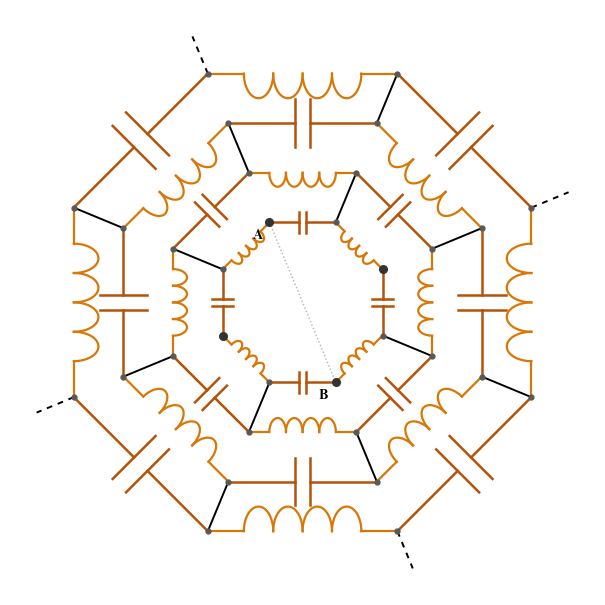

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams["font.family"] = "Times New Roman"

def _frame(p0, p1):
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    d = p1 - p0
    Lg = np.hypot(*d)
    t = d / Lg
    n = np.array([-t[1], t[0]])
    return p0, p1, Lg, t, n
def coil(ax, p0, p1, w=0.13, nb=4, **kw):
    p0, p1, Lg, t, n = _frame(p0, p1)
    body = 0.62 * Lg
    lead = (Lg - body) / 2
    ax.plot(*np.array([p0, p0 + lead * t]).T, **kw)
    ax.plot(*np.array([p1 - lead * t, p1]).T, **kw)
    r = body / (2 * nb)
    th = np.linspace(np.pi, 0, 24)
    for i in range(nb):
        c = p0 + (lead + (2 * i + 1) * r) * t
        pts = c[:, None] + r * np.cos(th) * t[:, None] + w * Lg * np.sin(th) * n[:, None]
        ax.plot(pts[0], pts[1], **kw)
def cap(ax, p0, p1, w=0.16, gap=0.10, **kw):
    p0, p1, Lg, t, n = _frame(p0, p1)
    g = gap * Lg
    mid = (p0 + p1) / 2
    for sg in (-1, +1):
        base = mid + sg * g / 2 * t
        ax.plot(*np.array([p0 if sg < 0 else p1, base]).T, **kw)
        ax.plot(*np.array([base - w * Lg * n, base + w * Lg * n]).T, **kw)
def vertex_xy(r, j, r0=1.0, dr=0.62):
    a = np.deg2rad(22.5 + 45 * j)
    return (r0 + dr * (r - 1)) * np.array([np.cos(a), np.sin(a)])

fig, ax = plt.subplots(figsize=(7.6, 7.6))
RINGS = 4

for r in range(1, RINGS + 1):
    for j in range(8):
        p0, p1 = vertex_xy(r, j), vertex_xy(r, (j + 1) % 8)
        if (r + j) % 2:
            coil(ax, p0, p1, color="#D97706", lw=1.6)  
        else:
            cap(ax, p0, p1, color="#B45309", lw=1.8) 
for r in range(1, RINGS):
    for j in range(8):
        if (r + j) % 2 == 0:
            ax.plot(*np.array([vertex_xy(r, j), vertex_xy(r + 1, j)]).T, color="#000000", lw=1.4)
for j in range(8):
    if (RINGS + j) % 2 == 0:
        a, b = vertex_xy(RINGS, j), vertex_xy(RINGS + 0.75, j)
        ax.plot(*np.array([a, b]).T, color="#000000", lw=1.4, ls=(0, (3, 3)))
for r in range(1, RINGS + 1):
    for j in range(8):
        free = (r == 1 and (r + j) % 2)
        ax.plot(*vertex_xy(r, j), 'o', ms=5.5 if free else 3.5, color="#333333" if free else "0.35", zorder=5)
for j, lab in ((2, "A"), (6, "B")):
    p = vertex_xy(1, j)
    ax.annotate(lab, p, textcoords="offset points", xytext=(-12, -12), fontsize=10, fontweight="bold")

ax.plot(*np.array([vertex_xy(1, 2), vertex_xy(1, 6)]).T, color="0.7", lw=1, ls=":")
ax.set_aspect("equal")
ax.axis("off")

plt.show()


Now, a plain wire is a short circuit, and radial links therefore merge $(r,j)$ with $(r{+}1,j)$ whenever $r+j$ is even. Because $r+j$ and $r{+}1+j$ have opposite parity, which means this merg will perfectly match in the radial direction i.e, each merged node consists of exactly two ring vertices, and the only
unmatched vertices are $(1,j)$ with $j$ even also the four degree-2 vertices of the
innermost ring, two of which are $A$ and $B$.

so now for the remaining surviving nodes $(n,w)$ lets denote it as  *$n=0$* for the four free inner vertices, $(0,w)=(1,w)$ with $w$ as even; *$n=r\ge1$* as the merged pair $\{(r,w),(r{+}1,w)\}$, which will be there if $r+w$ is even, and hence for the node set which is $$\mathcal{V}=\{(n,w):\;n\ge0,\;w\in\mathbb{Z}_8,\;n+w\ \text{even}\}$$ a four nodes per layer $n$ pushing each ring edge through the merging & for the edge
$(r,w)\!-\!(r,w{+}1)$ of ring $r=n$ is the **capacitor** (*since $n+w$ is even*) and its far end belongs to the merged node $(n{-}1,w{+}1)$ for the edge $(r,w)\!-\!(r,w{-}1)$ is an **inductor** on $(n{-}1,w{-}1)$ while the two edges of ring $n{+}1$ at the same angle is on $(n{+}1,w{-}1)$ i.e., a capacitor and $(n{+}1,w{+}1)$ an inductor. so we can observe that every node of $\mathcal{V}$ therefore has exactly the same criteria which is :

$$(n,w)\;\overset{L}{-}\;(n{+}1,w{+}1)\qquad
  (n,w)\;\overset{C}{-}\;(n{+}1,w{-}1)$$

Now lets Put $$p=\frac{n+w}{2}\qquad q=\frac{n-w}{2}\qquad\Longleftrightarrow\qquad n=p+q,\; w=p-q$$

(*$n+w$ even makes $p,q$ integers*) so we can rewrite above eq as,

$$(p,q)\overset{L}{-}(p{+}1,q) \qquad (p,q)\overset{C}{-}(p,q{+}1)$$

### Geometry : 
For a  plain square lattice with every horizontal makes an inductor $L$ and every vertical makes a capacitor $C$, while the fact that its a cylinder & its a semi-infinite 
remain of the original geometry, **For cylinder** $w$ lives in $\mathbb{Z}_8$, i.e. $(p,q)\sim(p{+}4,q{-}4)$ the lattice is rolled up along the diagonal with a period of $4$ cells (8 nodes,
4 per layer), **For semi-infinite** $n=p+q\ge0$ like a  staircase edge along the anti-diagonal, and an infinite outwards. here staircase *is* the innermost octagon i.e.,  walking along it one crosses $L,C,L,C,\dots$and lastly the terminals are basically two boundary sites i.e.,  $A=(0,2)$ and $B=(0,6)$ in $(n,w)$ coordinates,
i.e. $(p,q)=(1,-1)$ and $(3,-3)$.

where, 
* <span style="height: 10px; width: 10px; background-color: #D97706; border-radius: 50%; display: inline-block;"></span> Denotes **Inductor** 
* <span style="height: 10px; width: 10px; background-color: #B45309; border-radius: 50%; display: inline-block;"></span> Denotes **Capacitor**


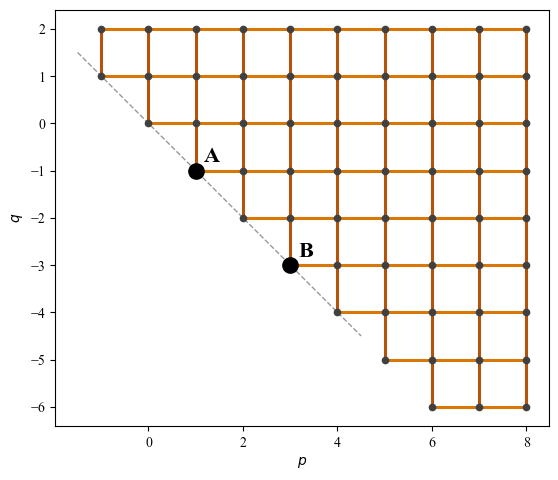

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(9.2, 5.4))
P = [(p, q) for p in range(-1, 9) for q in range(-6, 3) if p + q >= 0]
S = set(P)

for (p, q) in P:
    if (p+1, q) in S:
        ax.plot([p, p+1], [q, q], color="#D97706", lw=2.2, solid_capstyle="round")
    if (p, q+1) in S:
        ax.plot([p, p], [q, q+1], color="#B45309", lw=2.2, solid_capstyle="round")
ax.plot(*np.array(P).T, 'o', ms=4.5, color="0.25", zorder=4)
xs = np.array([-1.5, 4.5])
ax.plot(xs, -xs, color="0.6", lw=1, ls="--")
for (p, q), lab in (((1, -1), "A"), ((3, -3), "B")):
    ax.plot(p, q, 'o', ms=11, color="k", zorder=6)
    ax.annotate(lab, (p, q), textcoords="offset points", xytext=(6, 6),
                fontsize=16, fontweight="bold")
ax.set_xlabel("$p$")
ax.set_ylabel("$q$")
ax.set_aspect("equal")

plt.show()




lets write $\varphi(n,w)$ for the laplace domain node potentials, where

$$u=s\sqrt{LC}\ \qquad k=\sqrt{L/C}
\qquad\text{so} \quad sL=ku\quad, \frac{1}{sC}=\frac{k}{u}$$

### Nodes
**Interior nodes** $(n\ge1)$ have four bonds which includes two inductors to $(n\pm1,w\pm1)$ and two
capacitors to $(n\pm1,w\mp1)$ & applying Kirchhoff's current rule, multiplied through by $sL$ we'll get,

$$2(1+u^2)\,\varphi(n,w)=\Big[\varphi(n{+}1,w{+}1)+u^2\varphi(n{+}1,w{-}1)\Big]
+\Big[\varphi(n{-}1,w{-}1)+u^2\varphi(n{-}1,w{+}1)\Big]$$

**Boundary nodes** $(n=0)$ have only the two bonds both are outwards so if a current $J(w)$ is there we'll get,

$$(1+u^2)\,\varphi(0,w)-\Big[\varphi(1,w{+}1)+u^2\varphi(1,w{-}1)\Big]=sL\,J(w)$$

Both the equations are invariant under $w\to w+2$ & each layer holds four sites
i.e., ($w\equiv n \bmod 2$) and hence for the four discrete angular modes we can write it as, 

$$\varphi(n,w)=\Phi(n)\,e^{i\kappa w} \qquad \kappa=\kappa_m=\frac{\pi m}{4} \qquad\text{where}
\quad m=0,1,2,3$$

$$\alpha=e^{i\kappa}+u^2e^{-i\kappa} \qquad \beta=e^{-i\kappa}+u^2e^{i\kappa}$$

and now the interior equations become a plain three-term recursion in the radial index i.e.,

$$\alpha\,\Phi(n{+}1)-2(1+u^2)\,\Phi(n)+\beta\,\Phi(n{-}1)=0 $$

where, $\Phi(n)=\rho^{\,n}$ and $\alpha\rho^2-2(1+u^2)\rho+\beta=0$

$$\alpha\rho_\pm=(1+u^2)\pm\sqrt{(1+u^2)^2-\alpha\beta}$$

Since $\alpha\beta=1+u^4+2u^2\cos2\kappa$

$$(1+u^2)^2-\alpha\beta=2u^2\left(1-\cos 2\kappa\right)=\big(2u\sin\kappa\big)^2 $$

Therefore,

$$\alpha\rho_\pm=(1+u^2)\pm 2u\sin\kappa\qquad \rho_+\rho_-=\frac{\beta}{\alpha}
\quad \left|\frac{\beta}{\alpha}\right|=1 $$

which means one root lies inside the unit circle and other outside so the flow of energy must be *outwards*
i.e., nothing is coming in from infinity so,

$$\Phi(n)=\Phi(0)\,\rho^{\,n} \qquad \alpha\rho=(1+u^2)-2u\sin\kappa$$

Applying that in the boundary equation

$$\big[(1+u^2)-\alpha\rho\big]\Phi(0)=sL\,J$$
$$\quad 2u\sin\kappa\;\Phi(0)=sL\,J$$

$$\boxed{\;Y_m\equiv\frac{J}{\Phi(0)}=\frac{2u\sin\kappa_m}{sL}
=2\sin\!\big(\kappa_m\big)\sqrt{\frac{C}{L}}\;}$$

_**And hence each angular mode of the semi-infinite lattice presents a
pure conductance at the boundary**_.

### For $Z_{AB}$

Taking $+I$ at $A=(0,w_A)$ and $-I$ at $B=(0,w_B)$, so
$J(w)=I\left(\delta_{w,w_A}-\delta_{w,w_B}\right)$ on the boundary layer and with the mode
amplitudes i.e., $J_m=\tfrac14\sum_w J(w)e^{-i\kappa_m w}
=\tfrac{I}{4}\left(e^{-i\kappa_m w_A}-e^{-i\kappa_m w_B}\right)$

Applying 
$\Phi_m(0)=J_m/Y_m$ we'll get,

$$V=\varphi(0,w_A)-\varphi(0,w_B)
=\sum_{m}\frac{J_m}{Y_m}\left(e^{i\kappa_m w_A}-e^{i\kappa_m w_B}\right)
=\frac{I}{4}\sum_{m}\frac{\left|e^{i\kappa_m w_A}-e^{i\kappa_m w_B}\right|^2}{Y_m}$$

Taking $\Delta=w_A-w_B$ and using
$\left|e^{i\kappa_m w_A}-e^{i\kappa_m w_B}\right|^2=4\sin^2(\kappa_m\Delta/2)$:

$$\boxed{\;Z(\Delta)=\frac{k}{2}\sum_{m=1}^{3}\frac{\sin^2(\kappa_m\Delta/2)}{\sin\kappa_m}}$$

where $\kappa_m=\dfrac{\pi m}{4}\quad  k=\sqrt{L/C}\;$

since terminals are diametrically opposite, $\Delta=4$, and $\sin^2(\kappa_m\cdot2)=1,0,1$ for $m=1,2,3$ so we get $Z_{AB}$ as 

$$\boxed{Z_{AB}=\dfrac{k}{2}\left(\dfrac{1}{\sin\dfrac{\pi}{4}}+0+\frac{1}{\sin\dfrac{3\pi}{4}}\right)
    =\dfrac{k}{2}\left(\sqrt2+\sqrt2\right)=\sqrt2\,k=\sqrt{\dfrac{2L}{C}}}$$




### Conclusion

Network between $A$ and $B$ (acting as a pure resistance) is:

$$ Z_{AB}(s) = \sqrt{\frac{2L}{C}}  \quad \text{for every } s $$

And the input current $I(t)$ is : 
$$I(s) = \frac{V_0}{s \, Z_{AB}} = \frac{V_0}{\sqrt{2L/C}} \cdot \frac{1}{s}$$
$$I(t) = V_0\sqrt{\frac{C}{2L}} \qquad (t>0)$$ 
$$\fbox{$I(t) = V_0 \sqrt{\frac{C}{2L}} = \frac{V_0}{\sqrt{2L/C}} \, \theta(t) \quad \text{constant for all } t > 0$}$$

$$\text{With taking} \qquad L = 1\text{ mH}, \, C = 1\text{ }\mu\text{F}, \, V_0 = 10\text{ V: } R = \sqrt{2 \cdot 10^{-3} / 10^{-6}} = 44.72\text{ }\Omega \text{ and } I = 0.2236\text{ A.}$$